In [1]:
import os
import numpy as np
import tensorflow as tf
from pathlib import Path

os.chdir(next(p for p in Path.cwd().parents if (p / 'src').exists()))

from src.networks.DecoderPINN import PINN, compute_residual
from src.physics.physics import get_M_non_const
from src.visualization.pdeplots import get_eval_grid, plot_residual_map, plot_fixed_scar_comparison
from src.utils.metrics import compute_and_print_metrics
from src.hyperparameters import hypers_fixedscar as h
from src.visualization.pdeplots import N_GRID

tf.keras.backend.set_floatx('float64')
number_type = tf.float64

I0000 00:00:1791231974.887680    7667 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1791231974.888259    7667 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1791231974.955901    7667 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1791231976.329265    7667 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENAB

In [2]:
output_dir = 'models/pipeline_evolution/02_fixed_scar'
result_dir = 'results/pipeline_evolution/02_fixed_scar'
scale_path = 'data/fixed_scar/u_scale.npy'
dataset_path = 'data/fixed_scar/dataset.npz'
grid_path = 'data/fixed_scar/fem_grid.npy'

U_SCALE = float(np.load(scale_path)[0])

model = PINN(h.N_NEURONS_DECODER, U_SCALE)
model(tf.zeros((1,2)))

pretrained_weights = os.path.join(output_dir, 'decoder_lbfgs.weights.h5')
model.load_weights(pretrained_weights)
print(f"Model loaded from: {pretrained_weights}")

Model loaded from: models/pipeline_evolution/02_fixed_scar/decoder_lbfgs.weights.h5


E0000 00:00:1791231977.072898    7667 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


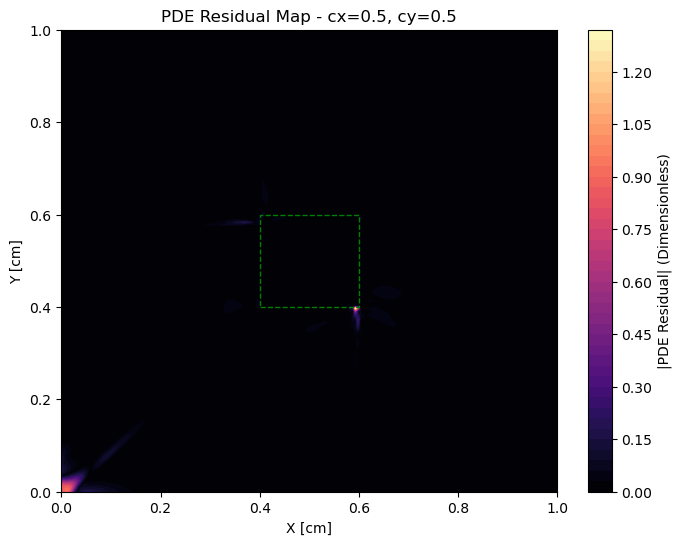

In [3]:
N_res = 200
X_res, Y_res, X_res_tensor = get_eval_grid(N_res)
pde_res = compute_residual(model, X_res_tensor, get_M_non_const)
Residual_Grid = np.abs(pde_res.numpy()).reshape(N_res, N_res)

plot_residual_map(X_res, Y_res, Residual_Grid)

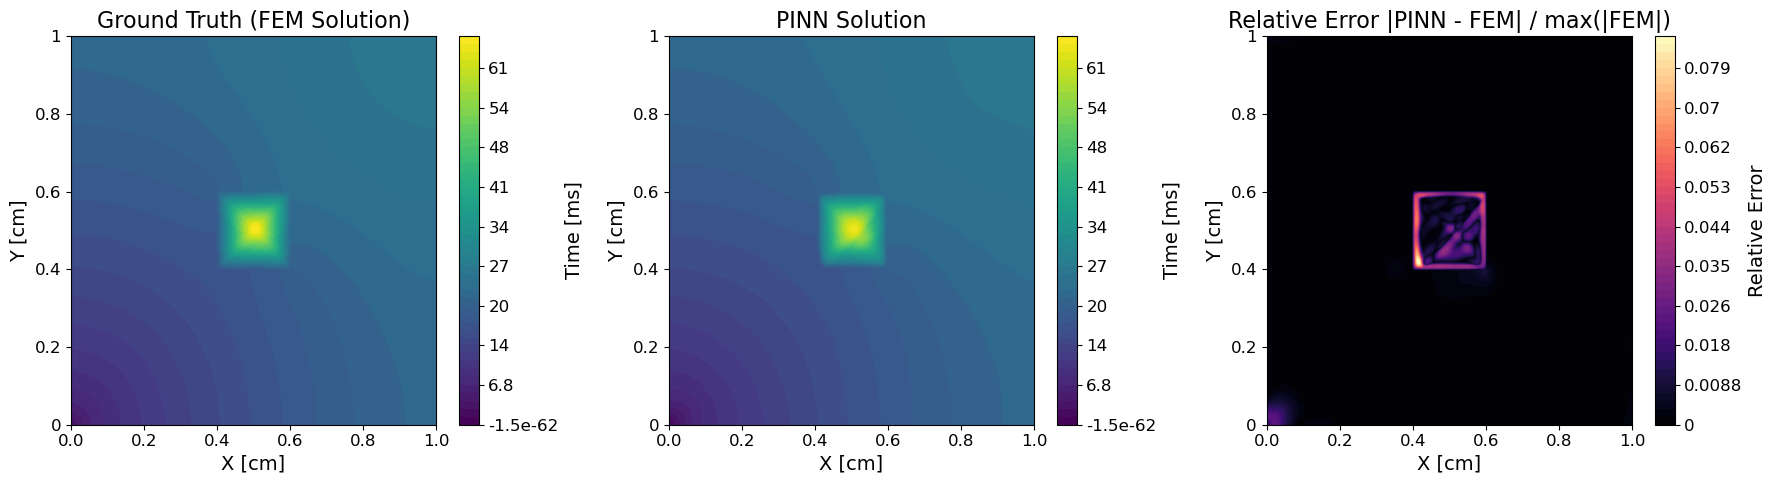

In [4]:
N_fem = 400
X_fem, Y_fem, X_fem_tensor = get_eval_grid(N_fem)

u_pinn = model(X_fem_tensor).numpy().flatten() * U_SCALE
u_fem = np.load(grid_path).flatten()

rel_err = np.abs(u_pinn - u_fem) / np.max((np.abs(u_fem)))

U_pinn2D = u_pinn.reshape(N_fem, N_fem) * 1000.0
U_fem2D = u_fem.reshape(N_fem, N_fem) * 1000.0
Rel_err2D = rel_err.reshape(N_fem, N_fem)

plot_fixed_scar_comparison(X_fem, Y_fem, U_pinn2D, U_fem2D, Rel_err2D)

In [5]:
# final evaluation on test data
test_mse, test_mae = compute_and_print_metrics(u_fem, u_pinn, U_SCALE)

Test MSE (Dimensionless) : 1.890841e-05
Test MAE (Physical)      : 0.0718 ms
